In [ ]:
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

# Load the image
image_path = "1_crop_5.png"
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Convert image to HSV for better color segmentation
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Define color ranges in HSV
color_ranges = {
    "red": [(0, 100, 100), (10, 255, 255)],
    "green": [(40, 40, 40), (90, 255, 255)],
    "blue": [(100, 100, 100), (140, 255, 255)]
}

# Dictionary to hold separated color images
separated_images = {}

# Process each color
for color, (lower, upper) in color_ranges.items():
    lower_np = np.array(lower)
    upper_np = np.array(upper)
    
    # Create a mask
    mask = cv2.inRange(hsv, lower_np, upper_np)
    
    # Apply the mask to extract the color
    result = cv2.bitwise_and(image_rgb, image_rgb, mask=mask)
    
    # Store result
    separated_images[color] = result

# Save separated images
output_paths = {}
for color, img in separated_images.items():
    output_path = f"separated_{color}.png"
    cv2.imwrite(output_path, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
    output_paths[color] = output_path

output_paths


[3729   38   49   37   23   21   34   24   22   17   15   15   19   24
   21   19   18   14   15    8   14   13   19   20   12   11   20   15
   11   13   12   13   25   17   11   26   16   24   26   37   34   34
   17   18   30   61   40   42   55   67  159 2220  308   82   48   37
   28   34   22   15   54   17   13   17    6   17   11   16    8   14
   11   12   14   15   10   12   18   12    7   12    8    9   18   13
   14   12   12   13   20   12   19   11   19   15   16   24   18   24
   18   30   33   39   46   49   62   63   63   92   91  138  163  176
  171  231  287  446 4374  281   42   25  252   12   14   17   15    8
   11    6    9    2    3    6    3    5    3    7    3    3    7    3
    4    2    2    1    4    2    1    4    3    2    2    2    3    0
    3    2    2    3    4    1    2   11    2    3    4    5    3    2
    4    5    6    2    3    5    5    9    6   21   22  148]


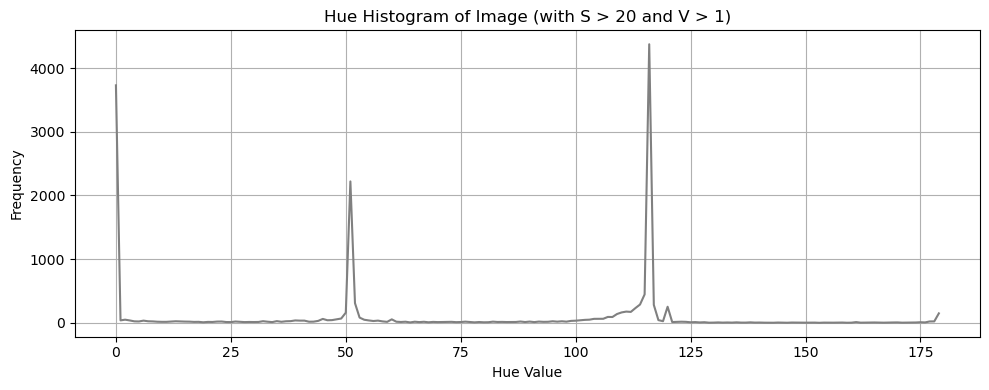

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the new image
image_path = "input_dir/1_crop_5.png"
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

# Compute the hue histogram
h, s, v = cv2.split(hsv)
mask = (s > 20) & (v > 1)
hue_values = h[mask]

hist = np.histogram(hue_values, bins=180, range=(0, 180))[0]
print(hist)
# Plot the hue histogram to investigate visibility of blue
plt.figure(figsize=(10, 4))
plt.plot(hist, color='gray')
plt.title("Hue Histogram of Image (with S > 20 and V > 1)")
plt.xlabel("Hue Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()


In [9]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.signal import find_peaks
import os
import cv2
import json
import re
from pathlib import Path

def compute_hue_histogram(hue_values, bins=180):
    return np.histogram(hue_values, bins=bins, range=(0, 180))[0]

def detect_peaks(hist, min_height_ratio=0.005, distance=5):
    peaks, _ = find_peaks(hist, height=min_height_ratio * np.max(hist), distance=distance)
    return peaks

def get_color_ranges(peaks, tolerance=15):
    return [(max(0, p - tolerance), min(179, p + tolerance)) for p in peaks]

def create_color_mask(hsv_img, low, high, s_thresh=20, v_thresh=1):
    if low > high:
        mask1 = cv2.inRange(hsv_img, (0, s_thresh, v_thresh), (high, 255, 255))
        mask2 = cv2.inRange(hsv_img, (low, s_thresh, v_thresh), (179, 255, 255))
        return cv2.bitwise_or(mask1, mask2)
    else:
        return cv2.inRange(hsv_img, (int(low), int(s_thresh), int(v_thresh)), (int(high), 255, 255))

def apply_mask_with_white_background(image, mask):
    white_bg = np.full_like(image, 255)
    masked = cv2.bitwise_and(image, image, mask=mask)
    inverse = cv2.bitwise_not(mask)
    return cv2.bitwise_or(masked, cv2.bitwise_and(white_bg, white_bg, mask=inverse))

def group_by_base_name(file_list):
    groups = {}
    for fname in file_list:
        base = re.sub(r'_crop_\d+', '', fname.split('.')[0])
        groups.setdefault(base, []).append(fname)
    return groups

def ensure_red_peak(peaks):
    peaks = list(peaks)
    if not any(p <= 10 or p >= 170 for p in peaks):
        peaks.append(0)
    return sorted(list(set(peaks)))

def save_histogram(hist, peaks, name, output_dir):
    try:
        plt.figure(figsize=(8, 3))
        plt.plot(hist)
        plt.scatter(peaks, hist[peaks], color='red')
        plt.title("Hue Histogram with Detected Peaks")
        plt.xlabel("Hue")
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, f"{name}_hist.png"))
        plt.close()
    except Exception as e:
        print(f"Could not save hue histogram: {e}")

def process_images_separation(input_dir, output_dir, output_json):
    os.makedirs(output_dir, exist_ok=True)
    output_data = []

    if os.path.exists(output_json):
        with open(output_json, 'r') as f:
            output_data = json.load(f)

    image_files = [f for f in os.listdir(input_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    groups = group_by_base_name(image_files)

    for base_name, crops in groups.items():
        crops.sort()
        hue_values = []

        for crop in crops:
            image = cv2.imread(os.path.join(input_dir, crop))
            if image is None:
                continue
            hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
            h, s, v = cv2.split(hsv)
            mask = (s > 20) & (v > 1)
            hue_values.extend(h[mask])

        hue_values = np.array(hue_values)
        if hue_values.size == 0:
            print(f"Skipped group {base_name} (no hue data across crops).")
            continue

        hist = compute_hue_histogram(hue_values)
        peaks = detect_peaks(hist)
        peaks = ensure_red_peak(peaks)
        color_ranges = get_color_ranges(peaks)

        for crop in crops:
            crop_img = cv2.imread(os.path.join(input_dir, crop))
            if crop_img is None:
                continue
            hsv_crop = cv2.cvtColor(crop_img, cv2.COLOR_BGR2HSV)

            for idx, (peak, (low, high)) in enumerate(zip(peaks, color_ranges), start=1):
                mask = create_color_mask(hsv_crop, low, high)
                nonzero_ratio = np.count_nonzero(mask) / mask.size
                if nonzero_ratio < 0.01:
                    continue

                result = apply_mask_with_white_background(crop_img, mask)
                fname = f"{Path(crop).stem}_cat_{idx}.png"
                out_path = os.path.join(output_dir, fname)
                cv2.imwrite(out_path, result)

                output_data.append({
                    "filename": fname,
                    "color_hsv": {"h": round(peak / 180, 2), "s": 1, "v": 1}
                })

    output_data.sort(key=lambda x: x["filename"])
    with open(output_json, "w") as f:
        json.dump(output_data, f, indent=4)
    print(f"Saved {len(output_data)} entries to {output_json}")


In [10]:
process_images_separation(
        input_dir="input_dir",
        output_dir="out_comb/output_dir",
        output_json="output_json",
    )

Saved 10 entries to output_json


In [ ]:
import os
import re
import json
from pathlib import Path
from glob import glob
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy.spatial.distance import cdist

# ... (Helper functions like extract_image_id, extract_crop_number, extract_category, get_latest_path remain the same) ...

# -----------------------------
# Step 1: JSON to CSV Conversion (MODIFIED)
# -----------------------------

def convert_json_to_csv(json_dir):
    pattern = re.compile(r'crop_(\d+)_cat_(\d+)')
    json_dir = Path(json_dir)

    for json_file in json_dir.glob("*.json"):
        with json_file.open("r", encoding="utf-8") as f:
            data = json.load(f)

        lines = data.get("lines", [])
        match = pattern.search(json_file.stem)
        crop = match.group(1) if match else "unknown"
        cat = match.group(2) if match else "unknown"

        rows = []
        for p1, p2 in lines:
            x1, y1 = p1
            x2, y2 = p2
            # It's good that you're normalizing x1 to be less than x2 if needed,
            # but for plotting, we need the original start/end for line segments.
            # However, for consistency, let's keep the x1 < x2 sorting if that's
            # what the model is meant to represent.
            # If the model sometimes outputs lines in reverse, this helps.
            # But here, we're just recording the raw segment.

            row = {
                "crop_num": int(crop), # Added crop_num for easier sorting and offset calculation later
                "cat": int(cat),       # Ensure category is an integer
                "x1": round(x1, 2),
                "y1": round(y1, 2),
                "x2": round(x2, 2),
                "y2": round(y2, 2)
            }
            rows.append(row)

        df = pd.DataFrame(rows)
        # We'll save it with a more descriptive name, e.g., 92_crop_6_cat_1_xy.csv
        csv_path = json_file.with_name(f"{json_file.stem}_xy.csv")
        df.to_csv(csv_path, index=False)
        print(f"✅ JSON converted to XY CSV: {csv_path}")

# ... (The rest of your original script and helper functions would go here,
#       but they might need to be adapted or replaced for XY plotting.) ...